# Supply Chain Demand Forecasting — v2 (Rigor Pass)

**Goal:** Move beyond a single Prophet model with unvalidated MAPE.  This notebook:

1. **Diagnoses** *why* the v1 MAPE was 168–481% (small baselines? volatility? structural breaks?)
2. **Benchmarks** 4 models with walk-forward cross-validation: Naive, Seasonal Naive, Prophet, SARIMA.
3. **Reframes** the deliverable from point forecasts to probabilistic **stock-out risk scores** — useful even under high model uncertainty.

All logic lives in the `forecasting/` Python package; this notebook is the presentation layer.

See [FORECASTING_EXPLAINED.md](./FORECASTING_EXPLAINED.md) for the methodology writeup.

In [1]:
import sys, os
from pathlib import Path

# Add project root to path so we can `import forecasting`
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from forecasting.data import load_weekly_demand, fill_weekly_gaps, get_category_series, TOP_CATEGORIES
from forecasting.diagnostics import diagnose_all
from forecasting.cv import evaluate_all_models
from forecasting.metrics import summarize_by_category
from forecasting.models import get_model
from forecasting.risk import build_risk_table

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (12, 4)

## 1. Load the weekly demand data

In [2]:
df = load_weekly_demand()                   # pulls from Snowflake; falls back to CSV
df = fill_weekly_gaps(df)                   # ensures continuous weekly index per category
print(f'{len(df):,} weekly rows across {df.category_id.nunique()} categories')
print(f'Date range: {df.order_week.min().date()} → {df.order_week.max().date()}')
df.head()

725 weekly rows across 5 categories
Date range: 2014-12-29 → 2017-10-02


,order_week,category_id,units_sold,orders,net_sales
0,2014-12-29,9,166,55,14453.399847
1,2015-01-05,9,254,85,22423.589842
2,2015-01-12,9,255,77,22179.349869
3,2015-01-19,9,274,90,23586.119873
4,2015-01-26,9,251,80,22085.639816


## 2. Diagnose: why was MAPE so high?

Run per-category diagnostics: baseline magnitude, coefficient of variation, outlier counts, structural break detection.

In [3]:
diag = diagnose_all(df)
cols = ['category_id','n_weeks','mean','median','std','cv','zero_pct','iqr_outlier_pct','struct_shift_pct','diagnoses']
diag[cols]

,category_id,n_weeks,mean,median,std,cv,zero_pct,iqr_outlier_pct,struct_shift_pct,diagnoses
0,9,145,259.220690,261.0,36.790033,0.141926,0.0,2.758621,-2.398348,BENIGN
1,17,145,508.510345,513.0,59.091868,0.116206,0.0,2.068966,-0.983867,BENIGN
2,24,145,434.179310,438.0,56.634632,0.130441,0.0,1.379310,0.438820,BENIGN
3,43,145,94.682759,95.0,11.780223,0.124418,0.0,1.379310,1.857448,BENIGN
4,45,145,119.482759,119.0,15.970504,0.133664,0.0,1.379310,-0.351288,BENIGN


### Visualize each category's series

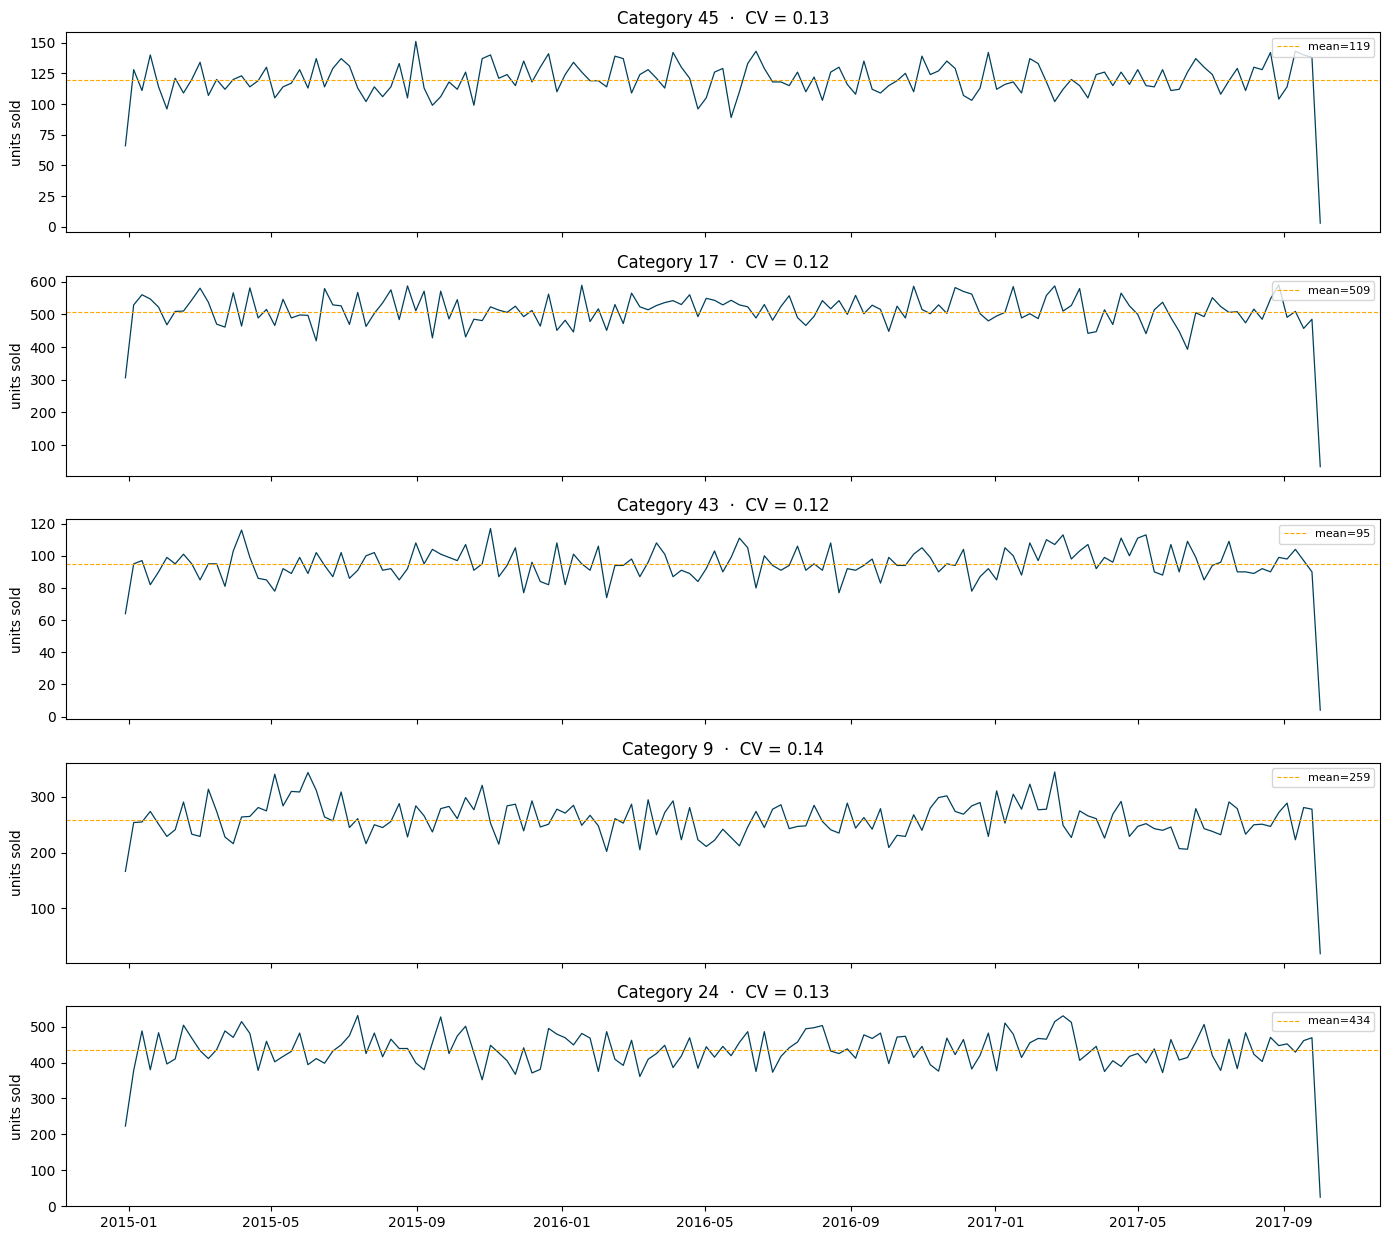

In [4]:
fig, axes = plt.subplots(len(TOP_CATEGORIES), 1, figsize=(14, 2.5 * len(TOP_CATEGORIES)), sharex=True)
for ax, cat in zip(axes, TOP_CATEGORIES):
    s = get_category_series(df, cat)
    ax.plot(s.index, s.values, lw=0.9, color='#003f5c')
    ax.axhline(s.mean(), color='#ffa600', ls='--', lw=0.8, label=f'mean={s.mean():.0f}')
    ax.set_title(f'Category {cat}  ·  CV = {(s.std()/s.mean() if s.mean() else float("nan")):.2f}')
    ax.set_ylabel('units sold')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Walk-forward cross-validation: 4 models × 5 categories

Per fold: train on the first $N$ weeks, forecast the next 4, compute error.  Step the train window forward 4 weeks and repeat.  Cap at 8 folds per (model, category) to keep runtime reasonable.

In [5]:
model_names = ['naive', 'seasonal_naive', 'prophet', 'sarima']

cv_results = evaluate_all_models(
    df,
    model_names=model_names,
    categories=TOP_CATEGORIES,
    initial_train_size=104,   # 2 years of training data minimum
    horizon=4,                # 4-week ahead forecast
    step=4,                   # step forward 4 weeks per fold
    max_folds=8,              # 8 folds × 4 models × 5 cats = 160 model fits
)
cv_results.head()

/Users/devashreepawar/Documents/supply-chain-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
16:20:05 - cmdstanpy - INFO - Chain [1] start processing
16:20:05 - cmdstanpy - INFO - Chain [1] done processing
16:20:05 - cmdstanpy - INFO - Chain [1] start processing
16:20:05 - cmdstanpy - INFO - Chain [1] done processing
16:20:05 - cmdstanpy - INFO - Chain [1] start processing
16:20:05 - cmdstanpy - INFO - Chain [1] done processing
16:20:05 - cmdstanpy - INFO - Chain [1] start processing
16:20:05 - cmdstanpy - INFO - Chain [1] done processing
16:20:05 - cmdstanpy - INFO - Chain [1] start processing
16:20:05 - cmdstanpy - INFO - Chain [1] done processing
16:20:05 - cmdstanpy - INFO - Chain [1] start processing
16:20:05 - cmdstanpy - INFO

,category_id,model,fold_id,train_end,test_start,test_end,train_size,mape,smape,mae,rmse
0,45,naive,0,2016-12-19,2016-12-26,2017-01-16,104,7.034722,7.645770,9.50,14.798649
1,45,naive,1,2017-01-16,2017-01-23,2017-02-13,108,8.350922,8.695917,10.75,12.913172
2,45,naive,2,2017-02-13,2017-02-20,2017-03-13,112,6.329695,6.004656,6.75,8.732125
3,45,naive,3,2017-03-13,2017-03-20,2017-04-10,116,6.378008,6.437730,7.50,8.689074
4,45,naive,4,2017-04-10,2017-04-17,2017-05-08,120,4.937119,5.173505,6.25,8.529361


### Summary table — median MAPE per (category, model)

In [6]:
summary = summarize_by_category(cv_results.to_dict('records'))
# Pivot so model names are columns
pivot = summary.pivot(index='category_id', columns='model', values='median_mape').round(1)
pivot = pivot[['naive', 'seasonal_naive', 'prophet', 'sarima']]
print('Median MAPE % per (category × model) across CV folds:\n')
pivot

Median MAPE % per (category × model) across CV folds:



model,naive,seasonal_naive,prophet,sarima
category_id,,,,
9,9.8,14.9,12.4,15.6
17,10.5,8.2,7.4,10.0
24,8.4,10.0,9.7,11.6
43,8.7,9.3,8.6,8.4
45,6.7,12.7,7.2,10.8


### Pick the best model per category

In [7]:
best = pivot.idxmin(axis=1).to_frame('best_model')
best['best_mape'] = pivot.min(axis=1).round(1)
best['vs_naive'] = (pivot.min(axis=1) - pivot['naive']).round(1)
best['vs_naive_pct'] = (100 * (pivot.min(axis=1) - pivot['naive']) / pivot['naive']).round(1)
best

,best_model,best_mape,vs_naive,vs_naive_pct
category_id,,,,
9,naive,9.8,0.0,0.0
17,prophet,7.4,-3.1,-29.5
24,naive,8.4,0.0,0.0
43,sarima,8.4,-0.3,-3.4
45,naive,6.7,0.0,0.0


## 4. Final 4-week forecast using the best model per category

For each category, refit the winning model on the full series and produce a 4-week forward forecast.

In [8]:
forecasts_by_category = {}
for cat in TOP_CATEGORIES:
    best_model_name = best.loc[cat, 'best_model']
    model = get_model(best_model_name)
    series = get_category_series(df, cat)
    model.fit(series)
    forecasts_by_category[cat] = model.predict(horizon=4)
    print(f'Cat {cat}: {best_model_name}, total 4w forecast = {forecasts_by_category[cat]["yhat"].sum():.0f} units')

16:21:02 - cmdstanpy - INFO - Chain [1] start processing
16:21:02 - cmdstanpy - INFO - Chain [1] done processing


Cat 45: naive, total 4w forecast = 12 units
Cat 17: prophet, total 4w forecast = 1882 units
Cat 43: sarima, total 4w forecast = 309 units
Cat 9: naive, total 4w forecast = 72 units
Cat 24: naive, total 4w forecast = 100 units


## 5. Reframe as probabilistic stock-out risk

Current inventory is approximated as `1.5× trailing 4-week mean` (same heuristic as v1).  We compute:
- **Stock-out probability** under current stock
- **Recommended order quantity** at three risk tolerance levels (5%, 10%, 20%)

In [9]:
# Current stock heuristic — replace with WMS feed in production
current_stock = {}
for cat in TOP_CATEGORIES:
    s = get_category_series(df, cat)
    current_stock[cat] = float(s.tail(4).mean() * 1.5)

risk_df = build_risk_table(forecasts_by_category, current_stock)
risk_df.round(1)

,category_id,forecast_4w_units,forecast_lower_80,forecast_upper_80,current_stock_units,stockout_prob_current,order_qty_at_5pct_risk,order_qty_at_10pct_risk,order_qty_at_20pct_risk,risk_band
1,17,1881.9,1620.3,2145.8,556.9,1.0,1663.0,1588.0,1498.0,CRITICAL (>50%)
2,43,309.1,211.1,407.1,110.6,1.0,325.0,297.0,263.0,CRITICAL (>50%)
3,9,72.0,0.0,260.7,300.0,0.0,0.0,0.0,0.0,LOW (<5%)
4,24,100.0,0.0,390.4,519.0,0.0,0.0,0.0,0.0,LOW (<5%)
0,45,12.0,0.0,93.9,159.0,0.0,0.0,0.0,0.0,LOW (<5%)


## 6. Persist outputs

In [10]:
data_dir = Path.cwd().parent / 'data'
data_dir.mkdir(exist_ok=True)

# Model comparison
pivot.to_csv(data_dir / 'model_comparison.csv')
print(f'✓ {data_dir / "model_comparison.csv"}')

# Stock-out risk table
risk_df.to_csv(data_dir / 'stockout_risk_scores.csv', index=False)
print(f'✓ {data_dir / "stockout_risk_scores.csv"}')

# Per-fold CV results (for any deeper inspection)
cv_results.to_csv(data_dir / 'cv_results.csv', index=False)
print(f'✓ {data_dir / "cv_results.csv"}')

# Best-model 4-week forecasts (replaces forecast_4w.csv functionality)
forecast_rows = []
for cat, fc in forecasts_by_category.items():
    for date, row in fc.iterrows():
        forecast_rows.append({
            'week': date.date(),
            'category_id': cat,
            'best_model': best.loc[cat, 'best_model'],
            'forecast_units': round(row['yhat'], 1),
            'lower_80': round(row['yhat_lower'], 1),
            'upper_80': round(row['yhat_upper'], 1),
        })
pd.DataFrame(forecast_rows).to_csv(data_dir / 'forecast_4w_v2.csv', index=False)
print(f'✓ {data_dir / "forecast_4w_v2.csv"}')

✓ /Users/devashreepawar/Documents/supply-chain-project/data/model_comparison.csv
✓ /Users/devashreepawar/Documents/supply-chain-project/data/stockout_risk_scores.csv
✓ /Users/devashreepawar/Documents/supply-chain-project/data/cv_results.csv
✓ /Users/devashreepawar/Documents/supply-chain-project/data/forecast_4w_v2.csv


## Summary

**Diagnoses:** see the diagnostics table above for which categories suffer from small baselines, high CV, outliers, or structural breaks.

**Model comparison:** pivot table shows median MAPE across CV folds for each (category, model) combo.  The `best` table picks the winning model per category and quantifies improvement vs Naive.

**Stock-out risk:** `stockout_risk_scores.csv` replaces the v1 `inventory_health.csv` with a probabilistic framing — a decision-relevant output even when point forecasts have wide intervals.

Methodology details and interpretation guidance: [FORECASTING_EXPLAINED.md](./FORECASTING_EXPLAINED.md).